In [ ]:
ls


Space_Mission_Data/  space_missions_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/space_missions_dataset.csv')

In [ ]:
df.head()

,Mission ID,Mission Name,Launch Date,Target Type,Target Name,Mission Type,Distance from Earth (light-years),Mission Duration (years),Mission Cost (billion USD),Scientific Yield (points),Crew Size,Mission Success (%),Fuel Consumption (tons),Payload Weight (tons),Launch Vehicle
0,MSN-0001,Mission-1,2025-01-01,Star,Titan,Colonization,7.05,5.2,526.68,64.3,21,100.0,731.88,99.78,SLS
1,MSN-0002,Mission-2,2025-01-08,Exoplanet,Betelgeuse,Colonization,41.76,23.0,234.08,84.4,72,89.6,4197.41,45.72,Starship
2,MSN-0003,Mission-3,2025-01-15,Asteroid,Mars,Exploration,49.22,28.8,218.68,98.6,16,98.6,4908.00,36.12,Starship
3,MSN-0004,Mission-4,2025-01-22,Exoplanet,Titan,Colonization,26.33,17.8,232.89,36.0,59,90.0,2569.05,40.67,Starship
4,MSN-0005,Mission-5,2025-01-29,Exoplanet,Proxima b,Mining,8.67,9.2,72.14,96.5,31,73.2,892.76,12.40,Starship


In [ ]:
df.tail()


,Mission ID,Mission Name,Launch Date,Target Type,Target Name,Mission Type,Distance from Earth (light-years),Mission Duration (years),Mission Cost (billion USD),Scientific Yield (points),Crew Size,Mission Success (%),Fuel Consumption (tons),Payload Weight (tons),Launch Vehicle
495,MSN-0496,Mission-496,2034-06-28,Planet,Betelgeuse,Colonization,48.26,25.3,274.82,91.2,64,96.2,4837.16,44.97,Ariane 6
496,MSN-0497,Mission-497,2034-07-05,Asteroid,Betelgeuse,Exploration,0.35,4.1,379.71,82.6,61,100.0,62.59,67.88,SLS
497,MSN-0498,Mission-498,2034-07-12,Planet,Ceres,Exploration,47.60,26.6,296.45,98.6,29,100.0,4794.01,51.38,Falcon Heavy
498,MSN-0499,Mission-499,2034-07-19,Planet,Betelgeuse,Research,31.99,18.0,457.38,77.9,39,100.0,3102.16,86.28,SLS
499,MSN-0500,Mission-500,2034-07-26,Planet,Io,Exploration,43.41,23.5,449.40,45.4,88,100.0,4302.93,86.74,Falcon Heavy


In [ ]:
df.shape


(500, 15)

In [ ]:
df.columns

Index(['Mission ID', 'Mission Name', 'Launch Date', 'Target Type',
       'Target Name', 'Mission Type', 'Distance from Earth (light-years)',
       'Mission Duration (years)', 'Mission Cost (billion USD)',
       'Scientific Yield (points)', 'Crew Size', 'Mission Success (%)',
       'Fuel Consumption (tons)', 'Payload Weight (tons)', 'Launch Vehicle'],
      dtype='object')

In [ ]:
df.head()

,Mission ID,Mission Name,Launch Date,Target Type,Target Name,Mission Type,Distance from Earth (light-years),Mission Duration (years),Mission Cost (billion USD),Scientific Yield (points),Crew Size,Mission Success (%),Fuel Consumption (tons),Payload Weight (tons),Launch Vehicle
0,MSN-0001,Mission-1,2025-01-01,Star,Titan,Colonization,7.05,5.2,526.68,64.3,21,100.0,731.88,99.78,SLS
1,MSN-0002,Mission-2,2025-01-08,Exoplanet,Betelgeuse,Colonization,41.76,23.0,234.08,84.4,72,89.6,4197.41,45.72,Starship
2,MSN-0003,Mission-3,2025-01-15,Asteroid,Mars,Exploration,49.22,28.8,218.68,98.6,16,98.6,4908.00,36.12,Starship
3,MSN-0004,Mission-4,2025-01-22,Exoplanet,Titan,Colonization,26.33,17.8,232.89,36.0,59,90.0,2569.05,40.67,Starship
4,MSN-0005,Mission-5,2025-01-29,Exoplanet,Proxima b,Mining,8.67,9.2,72.14,96.5,31,73.2,892.76,12.40,Starship


In [ ]:
df.shape

(500, 15)

In [ ]:
df.columns

Index(['Mission ID', 'Mission Name', 'Launch Date', 'Target Type',
       'Target Name', 'Mission Type', 'Distance from Earth (light-years)',
       'Mission Duration (years)', 'Mission Cost (billion USD)',
       'Scientific Yield (points)', 'Crew Size', 'Mission Success (%)',
       'Fuel Consumption (tons)', 'Payload Weight (tons)', 'Launch Vehicle'],
      dtype='object')

In [ ]:
df['Success_Label']= df['Mission Success (%)'].apply(
    lambda x: 1 if x > 85 else 0
)

In [ ]:
X = df[['Mission Cost (billion USD)',
        'Payload Weight (tons)',
        'Crew Size',
        'Fuel Consumption (tons)',
        'Scientific Yield (points)']]

In [ ]:
y = df['Success_Label']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
model = RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,predictions)
print(accuracy)

0.92


In [ ]:
importance = model.feature_importances_

for i,v in enumerate(importance):
    print(X.columns[i], ":", v)

Mission Cost (billion USD) : 0.5376216402781562
Payload Weight (tons) : 0.33300574863312105
Crew Size : 0.037945564657478545
Fuel Consumption (tons) : 0.05312487376860146
Scientific Yield (points) : 0.03830217266264286


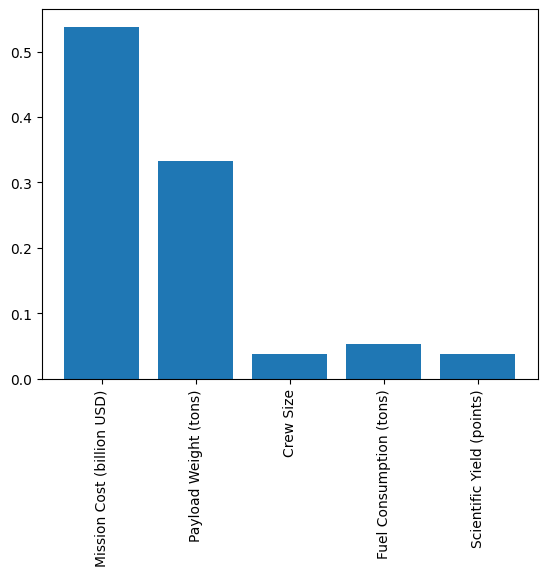

In [ ]:
import matplotlib.pyplot as plt

plt.bar(X.columns, importance)
plt.xticks(rotation=90)
plt.show()

In [ ]:
print(predictions[:10])

[1 1 0 0 0 0 1 0 1 1]


In [ ]:
print("Actual:", y_test.values[:10])
print("Predicted:", predictions[:10])

Actual: [1 1 0 0 0 1 1 0 1 1]
Predicted: [1 1 0 0 0 0 1 0 1 1]


In [ ]:
new_mission = [[500, 80, 5, 1000, 85]]

prediction = model.predict(new_mission)

print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
[1]

[1]

In [ ]:
[0]

[0]

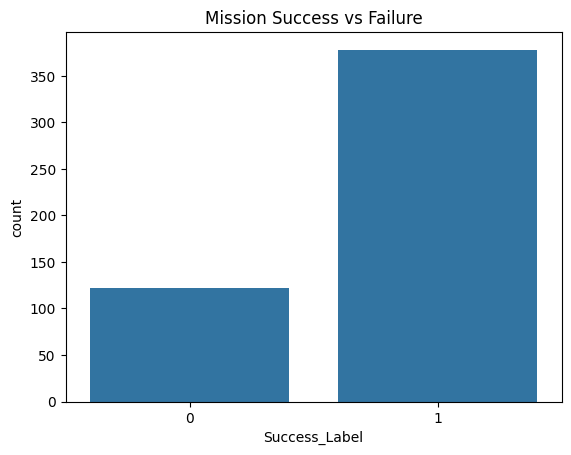

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Success_Label', data=df)
plt.title("Mission Success vs Failure")
plt.show()

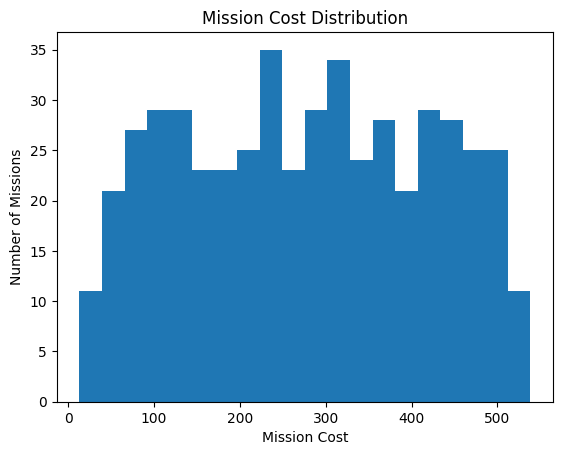

In [ ]:
plt.hist(df['Mission Cost (billion USD)'], bins=20)
plt.title("Mission Cost Distribution")
plt.xlabel("Mission Cost")
plt.ylabel("Number of Missions")
plt.show()

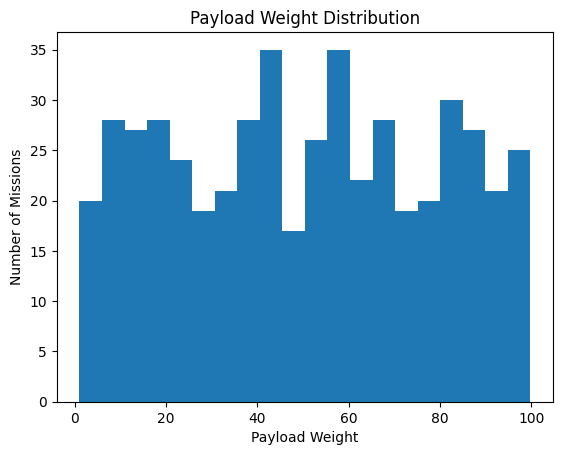

In [ ]:
plt.hist(df['Payload Weight (tons)'], bins=20)
plt.title("Payload Weight Distribution")
plt.xlabel("Payload Weight")
plt.ylabel("Number of Missions")
plt.show()

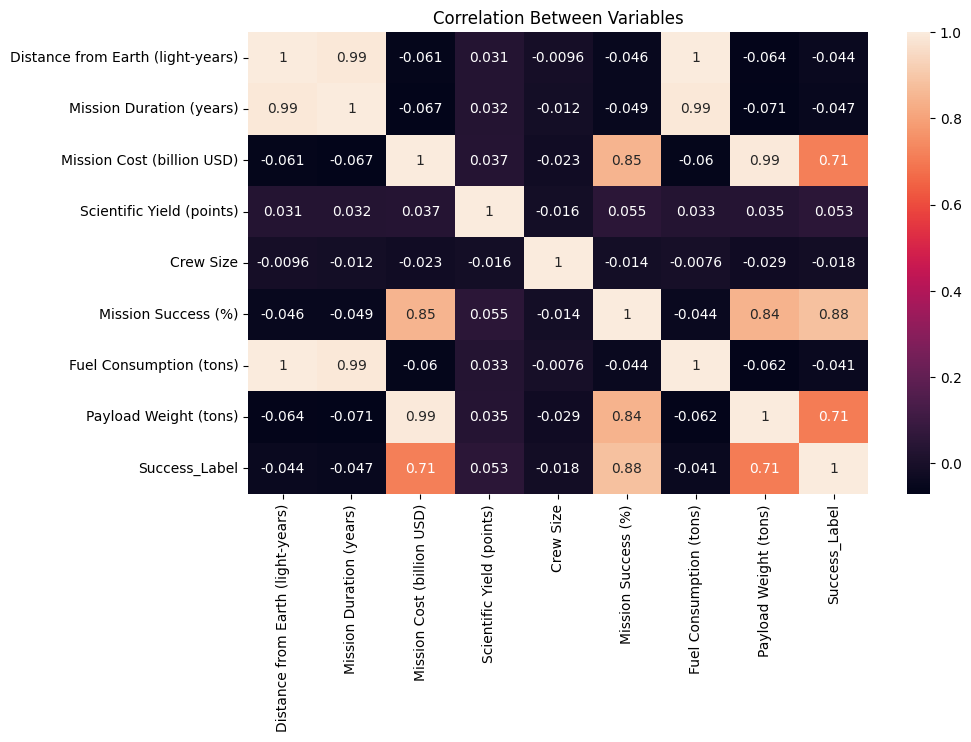

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Between Variables")
plt.show()

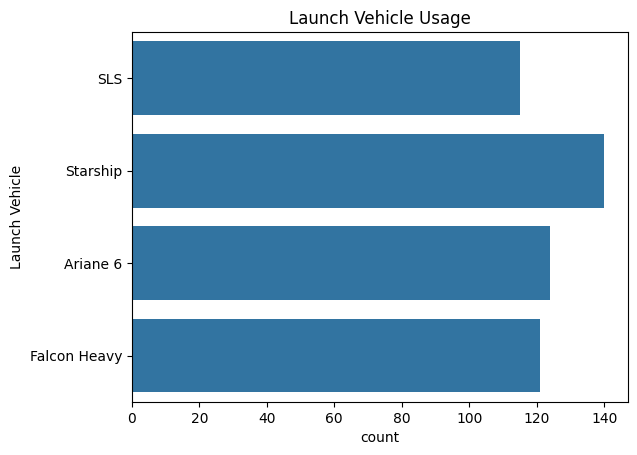

In [ ]:
sns.countplot(y='Launch Vehicle', data=df)
plt.title("Launch Vehicle Usage")
plt.show()

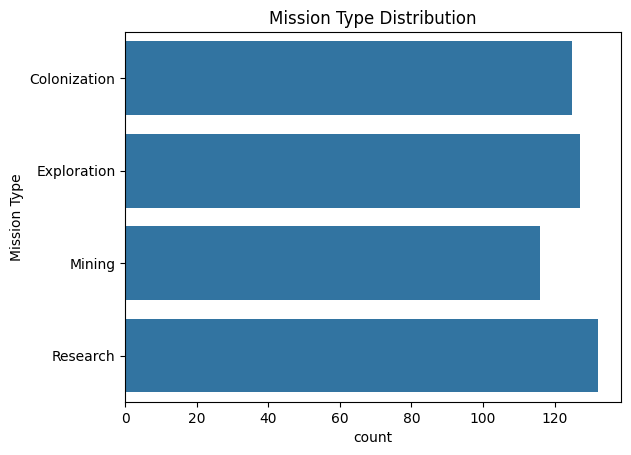

In [ ]:
sns.countplot(y='Mission Type', data=df)
plt.title("Mission Type Distribution")
plt.show()

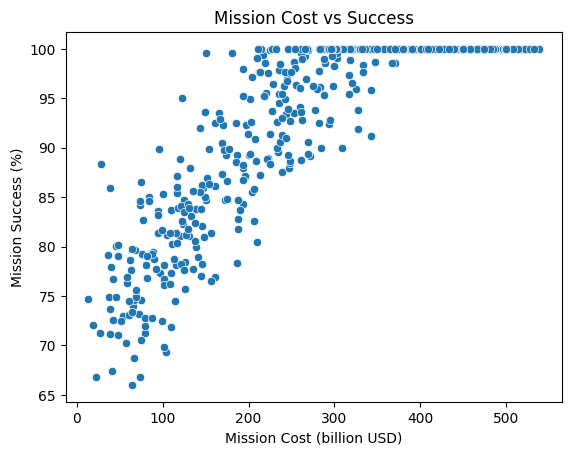

In [ ]:
sns.scatterplot(
    x='Mission Cost (billion USD)',
    y='Mission Success (%)',
    data=df
)
plt.title("Mission Cost vs Success")
plt.show()

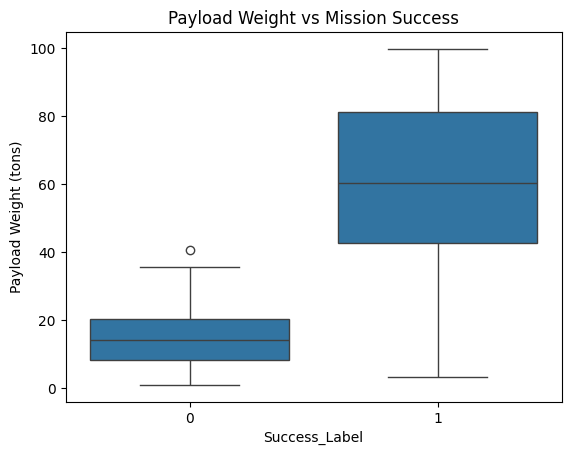

In [ ]:
sns.boxplot(
    x='Success_Label',
    y='Payload Weight (tons)',
    data=df
)
plt.title("Payload Weight vs Mission Success")
plt.show()